# ERA5 timeseries access from CDS using xcube

This notebook provides a walk-through demonstrating how to use xcube and the xcube Climate Data Store (CDS) plugin to read and explore temperature time series from ERA5 from the CDS.

Before using this notebook, ensure that you have set up xcube, the CDS plugin, and Jupyter Lab as described in the [Ex0-CDS-store-Setup](./Ex0-CDS-store-setup.ipynb) notebook.

First, we import some necessary libraries.

In [1]:
from xcube.core.store import new_data_store

Create a CDS data store object. The optional `normalize_names` parameter specifies that variable names in returned data cubes will be converted to legal Python identifiers, if required.

In [2]:
cds_store = new_data_store("cds", normalize_names=True)

Find out which datasets are available from this store. We get a list of tuples; the first member of each tuple is the data ID, and the second member is a short description of the dataset. We pick [ERA5 hourly time-series data on single levels from 1940 to present](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview).


In [3]:
data_ids = list(cds_store.get_data_ids())
data_ids

['reanalysis-era5-land',
 'reanalysis-era5-land-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-single-levels:ensemble_mean',
 'reanalysis-era5-single-levels:ensemble_members',
 'reanalysis-era5-single-levels:ensemble_spread',
 'reanalysis-era5-single-levels:reanalysis',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_ensemble_members',
 'reanalysis-era5-single-levels-monthly-means:monthly_averaged_reanalysis',
 'reanalysis-era5-single-levels-timeseries',
 'satellite-soil-moisture:saturation:daily',
 'satellite-soil-moisture:saturation:10-day',
 'satellite-soil-moisture:saturation:monthly',
 'satellite-soil-moisture:volumetric:daily',
 'satellite-soil-moisture:volumetric:10-day',
 'satellite-soil-moisture:volumetric:monthly',
 'satellite-sea-ice-thickness:envisat',
 'satellite-sea-ice-thickness:cryosat-2',
 'derived-drought-historical-monthly:reanalysis',
 'derived-drought-historical-monthly:ensemble_members']

In [4]:
data_id = 'reanalysis-era5-single-levels-timeseries'

Let's see what parameters we can specify when opening the dataset. Three are listed as required parameters: `time_range`, `location`, and `variable_names`. The enumeration in `properties → variable_names → items` lists the variables we can request. 

In [5]:
cds_store.get_open_data_params_schema(data_id)

Next, we open the data cube from the store. We can request any number of variables, but in this example we will focus on `2m_temperature`. We define the **location** at which the timeseries is evaluated. Note that the ERA5 reanalysis dataset has a resolution of 0.25°, so the location will be rounded to the nearest grid point. For the `time range`, we select the years 1940 to 2025. Dates are specified in ISO-8601 format.

In [6]:
%%time
cube = cds_store.open_data(
    data_id,
    variable_names=["2m_temperature"],
    location=[10.1, 53.55],
    time_range=["1940-01-01", "2025-12-31"],
)

xcube-cds version 1.1.1
2026-01-14 17:00:13,053 WARNING [2025-03-17T00:00:00] Please be aware that the generation of this dataset is using an alternative source for the ERA5 data and may be subject to changes over time (e.g. file format, data file structure, deprecation etc). This dataset should therefore be regarded as “experimental” and is **not recommended for use in a production environment**. 

Notification of changes via this catalogue entry banner and/or in the [Forum](https://forum.ecmwf.int/) will be provided on best efforts.
2026-01-14 17:00:13,053 INFO Request ID is 51061603-8ca5-4b2e-b8f3-f2ef9d20bc6f
2026-01-14 17:00:13,160 INFO status has been updated to accepted
2026-01-14 17:00:26,756 INFO status has been updated to running
2026-01-14 17:00:34,424 INFO status has been updated to successful


6231ec98bc561fe6633530f669289e.zip:   0%|          | 0.00/8.64M [00:00<?, ?B/s]

CPU times: user 333 ms, sys: 169 ms, total: 502 ms
Wall time: 35.4 s


Show a summary of the dataset in the notebook.

In [7]:
cube

<xarray.Dataset> Size: 9MB
Dimensions:    (time: 753888)
Coordinates:
  * time       (time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:00:00
    latitude   float64 8B ...
    longitude  float64 8B ...
Data variables:
    t2m        (time) float32 3MB dask.array<chunksize=(753888,), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

The can plot the full temperature timeseries as shown below.

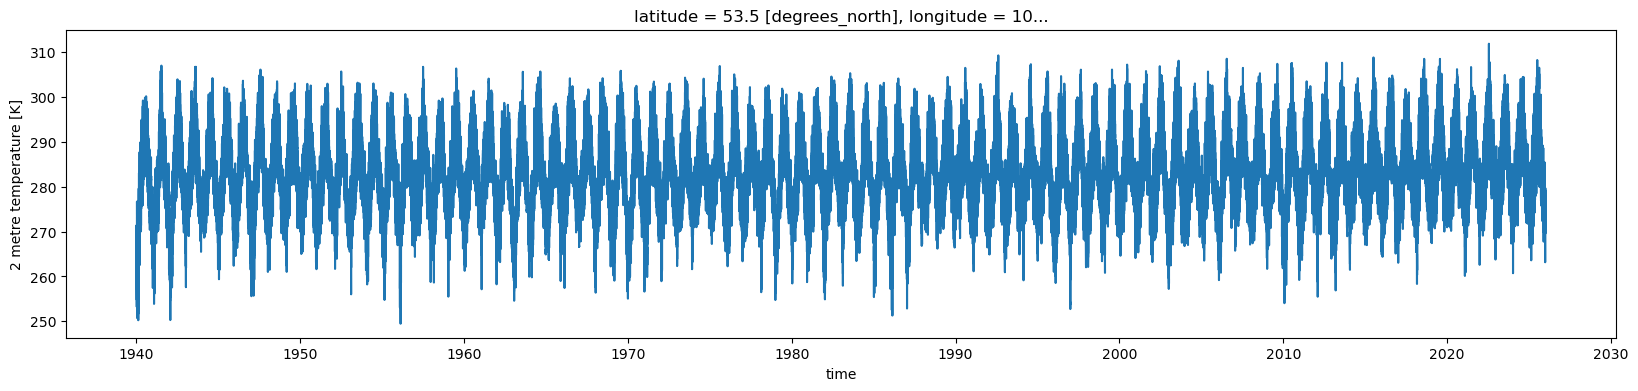

In [10]:
cube.t2m.plot(figsize=(20, 4))